<a href="https://colab.research.google.com/github/mulayvaibhav/agri_supply_chain_visual_inspection_system/blob/ishan/ML_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Exploratory Structural Analysis (ESA)

### 1 (a). Structural Audit

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/PS 1.xlsx')
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nFeature Types:")
print(df.dtypes)
print("\nDataset description:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nCount of records for different classes")
print(df['VariantLabel'].value_counts())

Shape: (900, 8)

Feature Types:
PixelMass           int64
LongAxisSpan      float64
ShortAxisSpan     float64
ShapeDeviation    float64
HullMass            int64
DensityRatio      float64
BoundaryLength    float64
VariantLabel       object
dtype: object

Dataset description:
           PixelMass  LongAxisSpan  ShortAxisSpan  ShapeDeviation  \
count     900.000000    900.000000     900.000000      900.000000   
mean    87804.127778    430.929950     254.488133        0.781542   
std     39002.111390    116.035121      49.988902        0.090318   
min     25387.000000    225.629541     143.710872        0.348730   
25%     59348.000000    345.442898     219.111126        0.741766   
50%     78902.000000    407.803951     247.848409        0.798846   
75%    105028.250000    494.187014     279.888575        0.842571   
max    235047.000000    997.291941     492.275279        0.962124   

            HullMass  DensityRatio  BoundaryLength  
count     900.000000    900.000000      900.00000

### 1 (b). Visualizations

#### Histogram: Tells whether features are normal, right-skewed or left-skewed

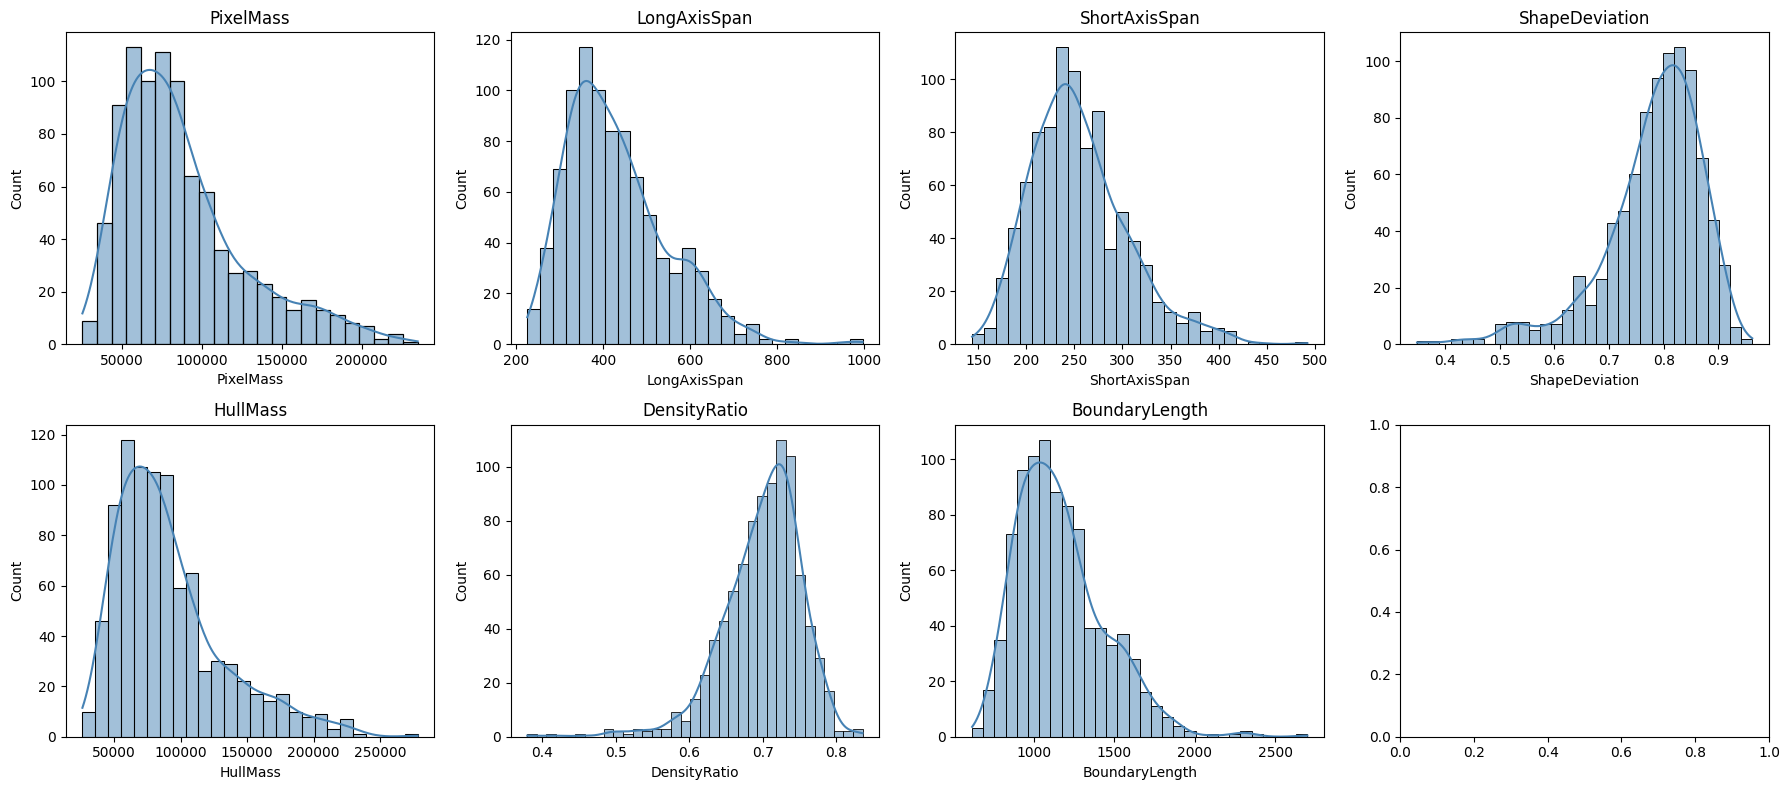

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

1. PixelMass and HullMass are rightly-skewed and needs to be transformed using Box-Cox transform.
2. LongAxisSpan and ShortAxisSpan: Two humps are visible in the graph: One for Kecimen and other is Besni. It is a stronger evidence that these features can discriminate the classes.
3. BoundaryLength: Right-skewed with bimodal hint i.e. similar to axis spans — slight two-peak shape, right tail present. Also needs skewness correction.
4. DensityRatio — Near normal, slight left skew
The most well-behaved feature. Roughly bell-shaped centered around 0.70. This means it won't need much transformation.
5. ShapeDeviation — Left-skewed / heavy left tail
Most values cluster near 0.75 – 0.90 but there's a tail toward 0.4. Opposite skew direction compared to size features.

#### Boxplot per feature split by class: If Besin sits higher than Kecimen, feature plays significant role in differentiating both classes.

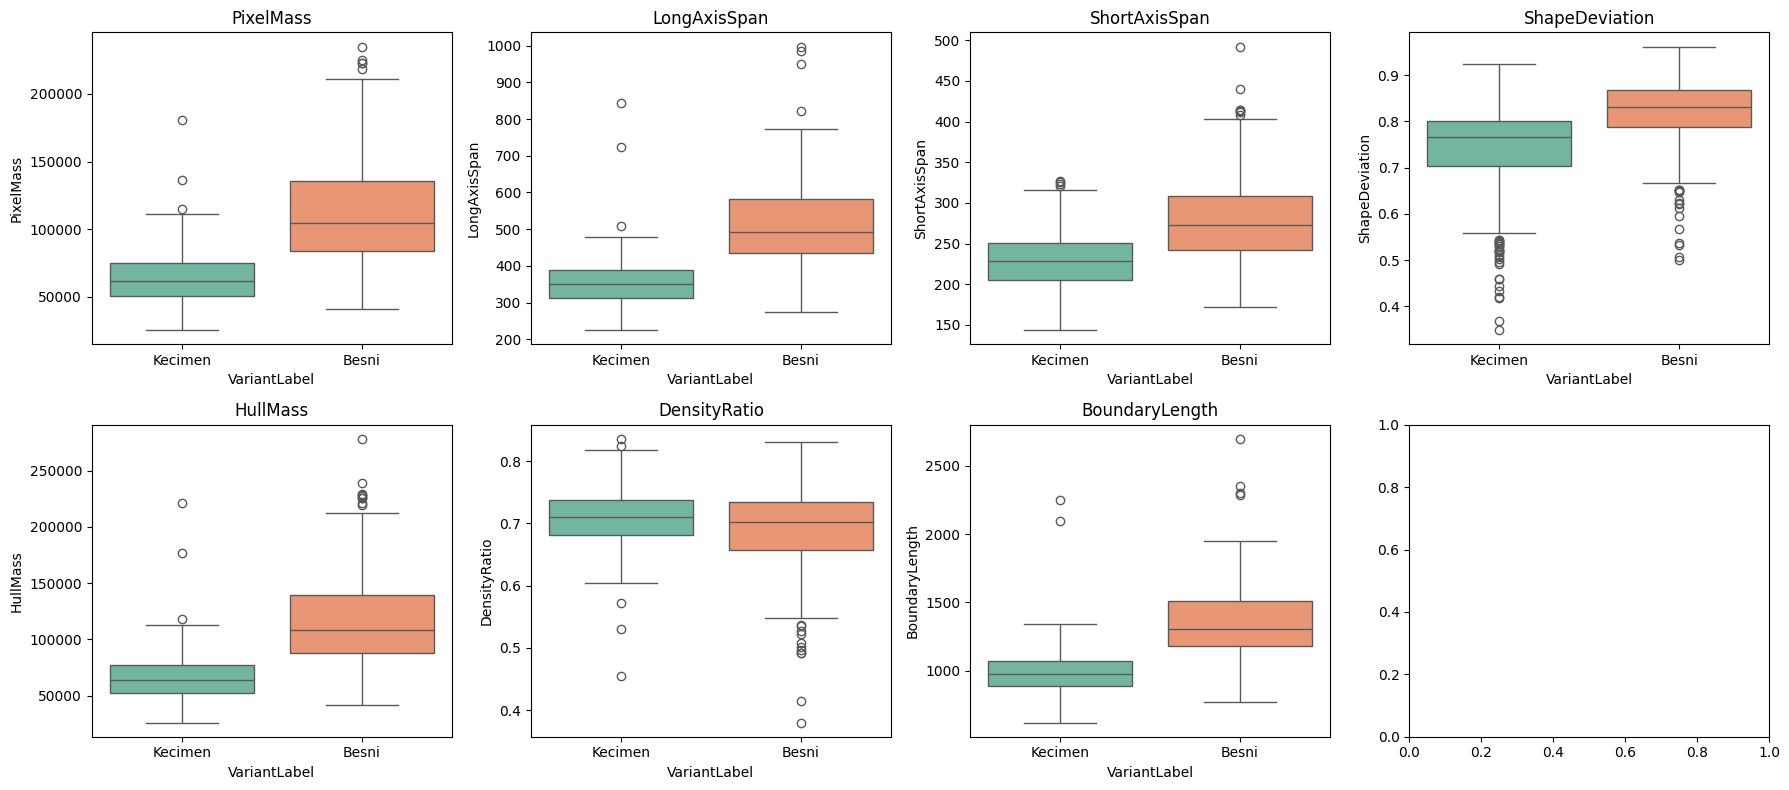

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(x='VariantLabel', y=col, data=df, ax=axes[i], palette='Set2', hue='VariantLabel', legend=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

1. PixelMass — Besni boxes sit clearly above Kecimen with minimal overlap; Besni raisins are significantly larger in area, making this a strong discriminator.
2. LongAxisSpan — Besni has a notably higher and wider box; Besni raisins are longer, with more variability in their length compared to Kecimen.
3. ShortAxisSpan — Similar to LongAxisSpan, Besni sits higher; Besni raisins are also wider, consistent with their larger overall size.
4. ShapeDeviation — Boxes overlap considerably but Besni clusters slightly higher; both varieties deviate from a perfect ellipse similarly, making this a weak discriminator.
5. HullMass — Nearly identical separation pattern as PixelMass; Besni has a larger convex hull, again confirming Besni is the bigger fruit.
6. DensityRatio — Boxes of both classes are almost identical in position and spread; this feature carries almost no class-discriminative information on its own.
7. BoundaryLength — Besni's box is clearly higher with little overlap; Besni has a longer perimeter, consistent with its larger size and elongated shape.

### 1 (c). Feature Interaction (Correlation Heatmap and Mutual Information)

If two features gives values greater than 0.9, they are highly correlated and provides redundant information. Here, PixelMass, HullMass and BoundaryLength shows high correlation

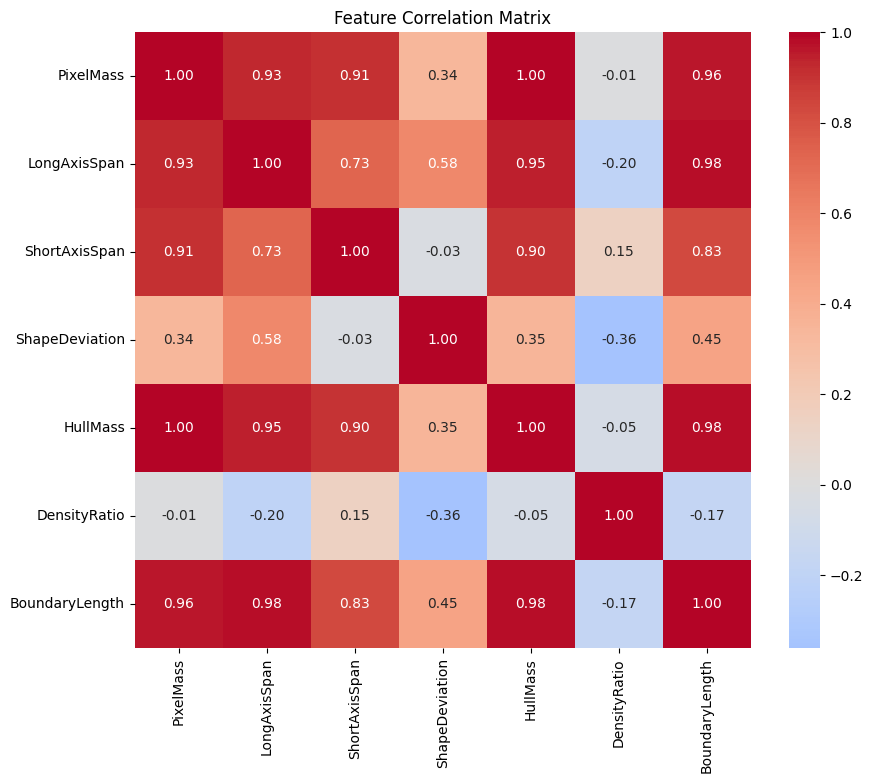

In [ ]:
corr_matrix = df.drop('VariantLabel', axis=1).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.show()

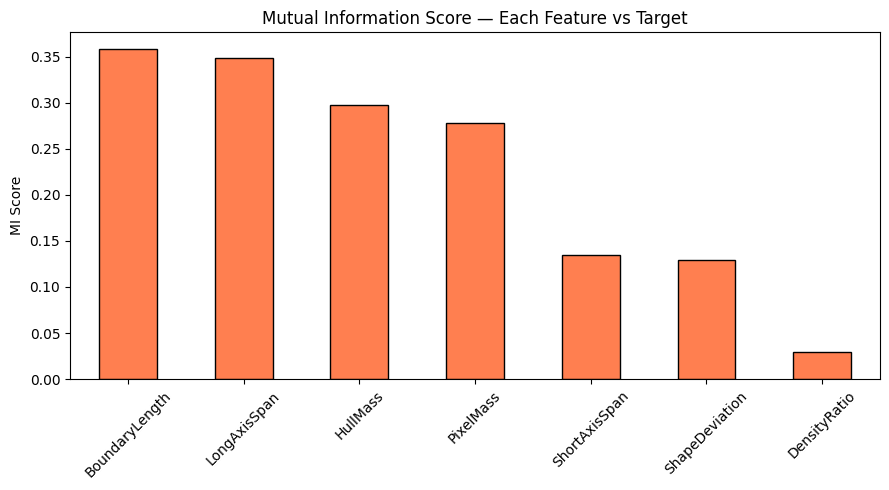

BoundaryLength    0.358507
LongAxisSpan      0.348341
HullMass          0.297530
PixelMass         0.277582
ShortAxisSpan     0.134869
ShapeDeviation    0.129117
DensityRatio      0.029344
dtype: float64


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['VariantLabel'])
X = df.drop('VariantLabel', axis=1)

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Visualize
plt.figure(figsize=(9, 5))
mi_series.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Mutual Information Score — Each Feature vs Target')
plt.ylabel('MI Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(mi_series)

## 2. Data Conditioning & Representation Learning

### 2 (a). Data Sanitization

Skewness Value and its Interpretation:

1. Between -0.5 and 0.5: Approximately Normal
2. Between 0.5 to 1.0: Moderately right-skewed
3. Above 1.0: High right-skewed - transformation needed
4. Negative Values: Left-skewed

In [ ]:
skewness = df.drop('VariantLabel', axis=1).skew()
print(skewness)

PixelMass         1.175237
LongAxisSpan      0.989544
ShortAxisSpan     0.800049
ShapeDeviation   -1.327503
HullMass          1.242904
DensityRatio     -1.151505
BoundaryLength    1.017761
dtype: float64


As noticed from histogram too, PixelMass, HullMass, LognAxisSpan, ShortAxisSpan and BoudnaryLength has shown high positive values which means they are right-skewed, and needs transformation.

### Outlier Detection (IQR)

In [ ]:
def detect_outliers_iqr(df, features):
    outlier_indices = {}
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)].index
        outlier_indices[col] = outliers
        print(f"{col}: {len(outliers)} outliers | Lower={lower:.2f}, Upper={upper:.2f}")
    return outlier_indices

features = df.drop('VariantLabel', axis=1).columns.tolist()
iqr_outliers = detect_outliers_iqr(df, features)

PixelMass: 41 outliers | Lower=-9172.38, Upper=173548.62
LongAxisSpan: 17 outliers | Lower=122.33, Upper=717.30
ShortAxisSpan: 26 outliers | Lower=127.94, Upper=371.05
ShapeDeviation: 43 outliers | Lower=0.59, Upper=0.99
HullMass: 42 outliers | Lower=-8780.50, Upper=178669.50
DensityRatio: 21 outliers | Lower=0.57, Upper=0.83
BoundaryLength: 17 outliers | Lower=453.44, Upper=1821.36


### Outlier Detection (Isolation Forest)

In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np

X = df.drop('VariantLabel', axis=1)

iso = IsolationForest(contamination=0.05, random_state=42)
df['iso_outlier'] = iso.fit_predict(X)
# -1 = outlier, 1 = normal

iso_outlier_count = (df['iso_outlier'] == -1).sum()
print(f"\nIsolation Forest detected: {iso_outlier_count} outliers")
print(df[df['iso_outlier'] == -1][features].head())

# Clean up the temp column
df.drop('iso_outlier', axis=1, inplace=True)


Isolation Forest detected: 45 outliers
     PixelMass  LongAxisSpan  ShortAxisSpan  ShapeDeviation  HullMass  \
34       46427    253.842028     235.906824        0.369212     48275   
59       25387    225.629541     144.618672        0.767577     26139   
85      180898    843.956653     323.190569        0.923770    221396   
156      45962    251.133384     235.368076        0.348730     47173   
192      37569    232.427848     208.152006        0.444950     38874   

     DensityRatio  BoundaryLength  
34       0.684219         844.312  
59       0.678144         619.074  
85       0.454189        2253.557  
156      0.742280         810.195  
192      0.794371         734.102  


### Compare both methods

In [ ]:
# Total unique outlier rows from IQR
all_iqr_outliers = set()
for indices in iqr_outliers.values():
    all_iqr_outliers.update(indices)

print(f"Total rows flagged by IQR: {len(all_iqr_outliers)}")
print(f"Total rows flagged by Isolation Forest: {iso_outlier_count}")

Total rows flagged by IQR: 105
Total rows flagged by Isolation Forest: 45


## Winsorization over dropping outliers:

Winsorization (capping) is used over dropping outliers because the dataset size is moderate (~900 rows) and dropping rows risks losing genuine biological variation in fruit morphology. Capping at the 1st and 99th percentile preserves the sample size while reducing the influence of extreme values on model training.

In [ ]:
# Apply Winsorization — cap at 1st and 99th percentile
from scipy.stats import mstats

df_clean = df.copy()
for col in features:
    df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.01, 0.01])

### Skewness Correction: Box-Cox

Box-Cox transformation is applied to the five right-skewed features — PixelMass, HullMass, LongAxisSpan, ShortAxisSpan, and BoundaryLength. Unlike log transform which applies a fixed formula, Box-Cox automatically finds the optimal λ (lambda) value per feature that makes its distribution most normal. The before/after histograms visually confirm the skewness reduction, and the printed skewness values numerically validate it. Since all these features contain strictly positive pixel measurements, the Box-Cox condition of positive-only values is naturally satisfied.

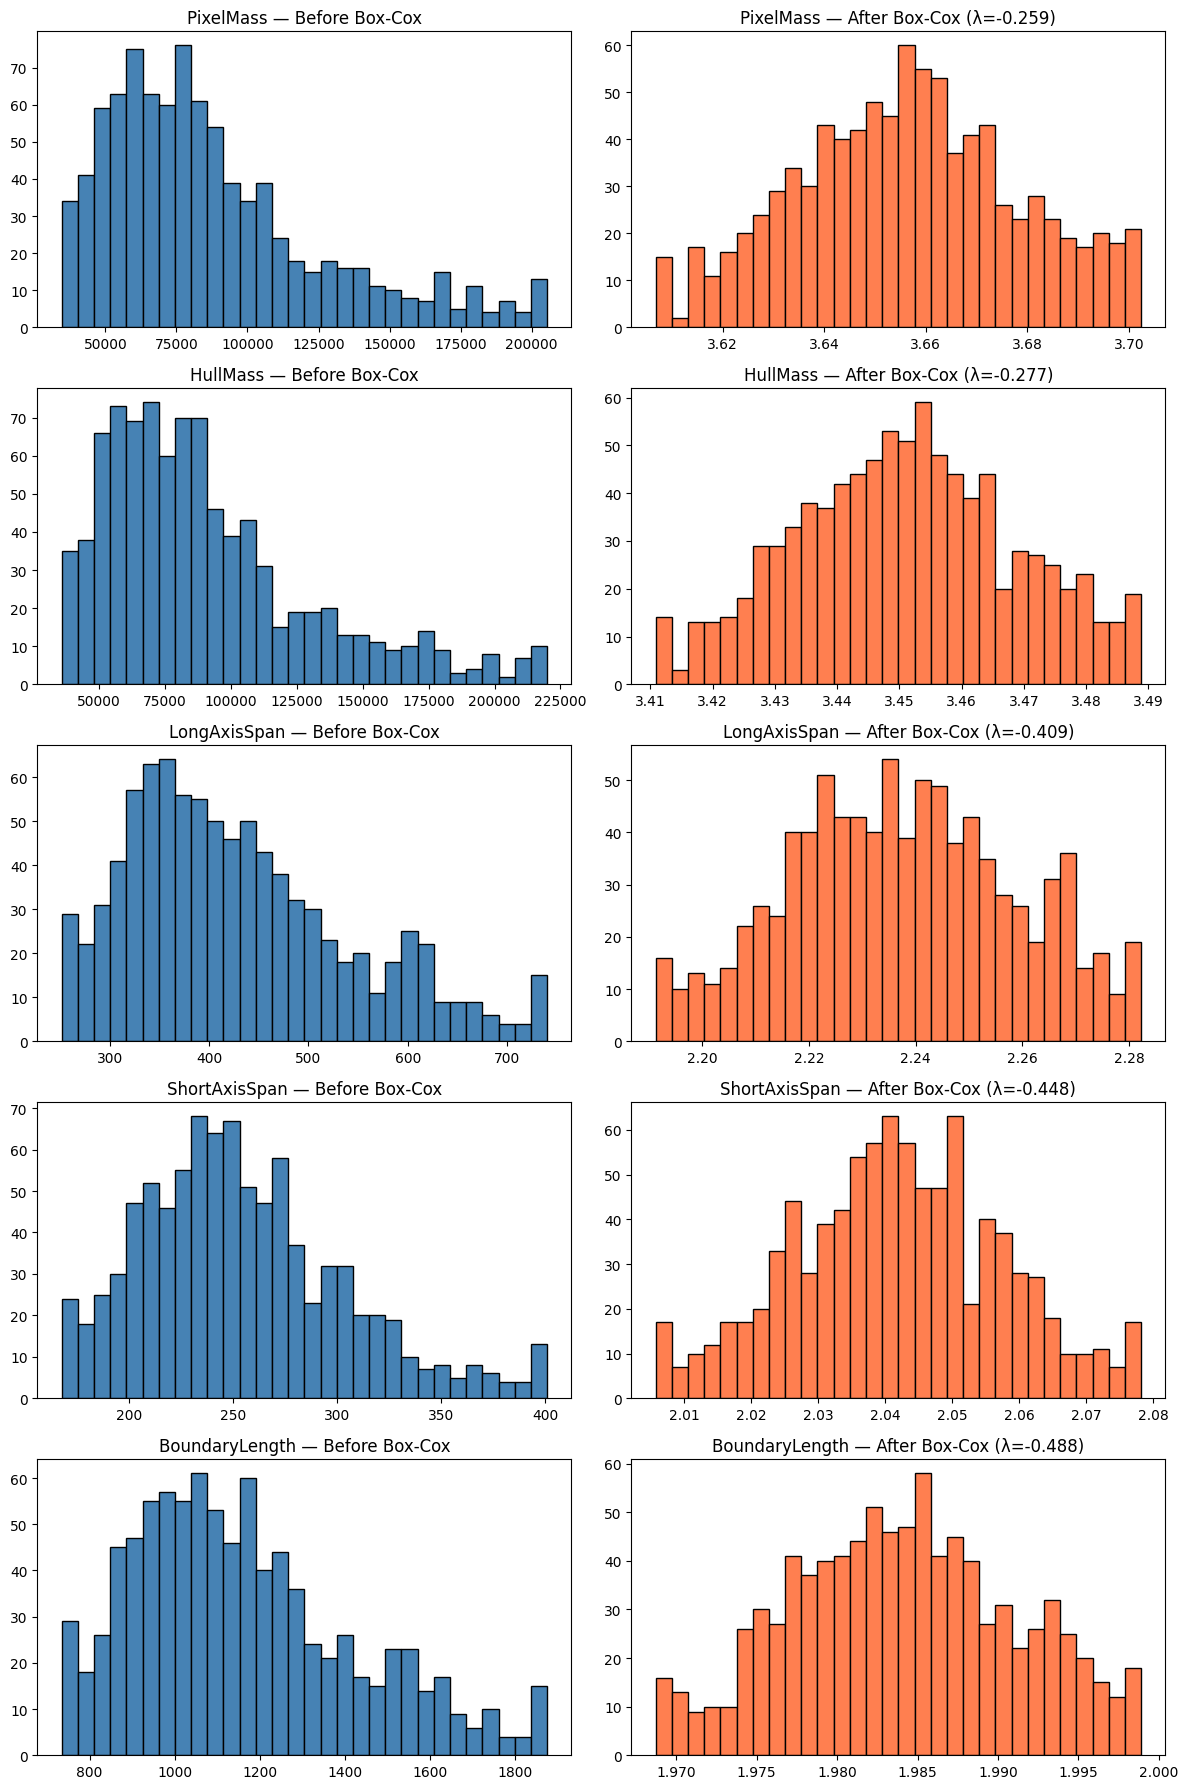

Box-Cox Lambda Values:
  PixelMass: λ = -0.2587
  HullMass: λ = -0.2772
  LongAxisSpan: λ = -0.4087
  ShortAxisSpan: λ = -0.4484
  BoundaryLength: λ = -0.4876

Skewness BEFORE:
PixelMass         1.127451
HullMass          1.174716
LongAxisSpan      0.740019
ShortAxisSpan     0.713269
BoundaryLength    0.692575
dtype: float64

Skewness AFTER Box-Cox:
PixelMass         0.020296
HullMass          0.021149
LongAxisSpan      0.022448
ShortAxisSpan     0.009253
BoundaryLength    0.022481
dtype: float64


In [ ]:
from scipy.stats import boxcox

skewed_features = ['PixelMass', 'HullMass', 'LongAxisSpan',
                   'ShortAxisSpan', 'BoundaryLength']

df_transformed = df_clean.copy()
lambda_values = {}  # store lambda values for reference

fig, axes = plt.subplots(len(skewed_features), 2, figsize=(12, 18))

for i, col in enumerate(skewed_features):
    # Before
    axes[i, 0].hist(df_clean[col], bins=30, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} — Before Box-Cox')

    # Apply Box-Cox (requires all values to be strictly positive)
    transformed_values, lambda_val = boxcox(df_clean[col])
    df_transformed[col] = transformed_values
    lambda_values[col] = lambda_val

    # After
    axes[i, 1].hist(transformed_values, bins=30, color='coral', edgecolor='black')
    axes[i, 1].set_title(f'{col} — After Box-Cox (λ={lambda_val:.3f})')

plt.tight_layout()
plt.show()

# Print lambda values
print("Box-Cox Lambda Values:")
for col, lam in lambda_values.items():
    print(f"  {col}: λ = {lam:.4f}")

# Compare skewness
print("\nSkewness BEFORE:")
print(df_clean[skewed_features].skew())
print("\nSkewness AFTER Box-Cox:")
print(df_transformed[skewed_features].skew())

### 2 (b). Standardization Technique

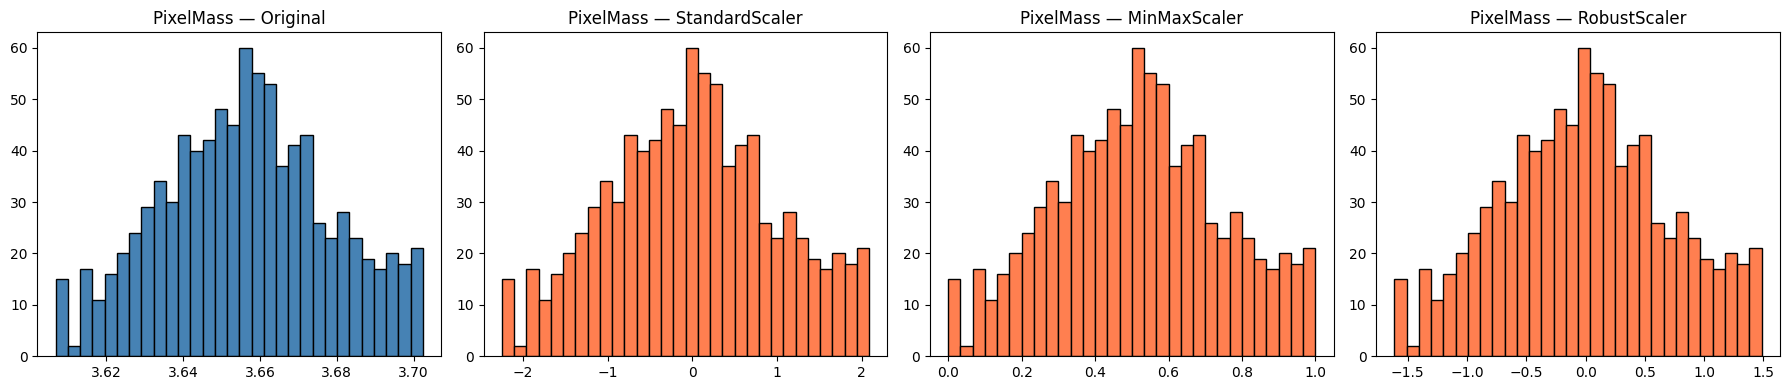

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import pandas as pd
import matplotlib.pyplot as plt

X = df_transformed.drop('VariantLabel', axis=1)
y = df_transformed['VariantLabel']

# Apply all three
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

scaled_dfs = {}
for name, scaler in scalers.items():
    scaled_arr = scaler.fit_transform(X)
    scaled_dfs[name] = pd.DataFrame(scaled_arr, columns=X.columns)

# Visualize distributions after each scaling — pick one feature to compare
feature_to_plot = 'PixelMass'

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(X[feature_to_plot], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title(f'{feature_to_plot} — Original')

for i, (name, scaled_df) in enumerate(scaled_dfs.items()):
    axes[i+1].hist(scaled_df[feature_to_plot], bins=30,
                   color='coral', edgecolor='black')
    axes[i+1].set_title(f'{feature_to_plot} — {name}')

plt.tight_layout()
plt.show()

In [ ]:
print("=== Mean and Std after scaling ===\n")
for name, scaled_df in scaled_dfs.items():
    print(f"{name}:")
    print(f"  Mean: {scaled_df.mean().round(4).values}")
    print(f"  Std:  {scaled_df.std().round(4).values}\n")

=== Mean and Std after scaling ===

StandardScaler:
  Mean: [ 0. -0.  0. -0.  0.  0.  0.]
  Std:  [1.0006 1.0006 1.0006 1.0006 1.0006 1.0006 1.0006]

MinMaxScaler:
  Mean: [0.5187 0.5093 0.4973 0.6829 0.5157 0.6513 0.5092]
  Std:  [0.2307 0.234  0.2165 0.2089 0.2271 0.1908 0.233 ]

RobustScaler:
  Mean: [-0.0054  0.0217  0.0017 -0.1664 -0.0025 -0.1172  0.0082]
  Std:  [0.7141 0.6972 0.7593 0.8676 0.7177 0.7929 0.7123]



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Final scaled data — mean and std:")
print(f"Mean:\n{X_scaled.mean().round(4)}")
print(f"\nStd:\n{X_scaled.std().round(4)}")

Final scaled data — mean and std:
Mean:
PixelMass         0.0
LongAxisSpan     -0.0
ShortAxisSpan     0.0
ShapeDeviation   -0.0
HullMass          0.0
DensityRatio      0.0
BoundaryLength    0.0
dtype: float64

Std:
PixelMass         1.0006
LongAxisSpan      1.0006
ShortAxisSpan     1.0006
ShapeDeviation    1.0006
HullMass          1.0006
DensityRatio      1.0006
BoundaryLength    1.0006
dtype: float64


### 2 (c). Feature Importance

#### Paradigm 1: Model based (Random Forest)

Random Forest Feature Importances:
BoundaryLength    0.249543
LongAxisSpan      0.241095
HullMass          0.160503
PixelMass         0.128043
ShapeDeviation    0.087115
ShortAxisSpan     0.072352
DensityRatio      0.061348
dtype: float64


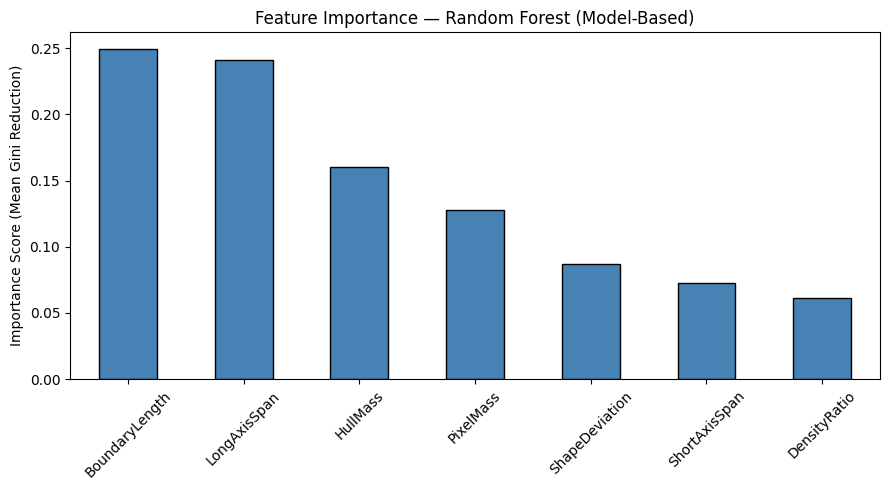

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Kecimen=0, Besni=1

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y_encoded)

# Extract importances
rf_importance = pd.Series(rf.feature_importances_,
                          index=X_scaled.columns).sort_values(ascending=False)

print("Random Forest Feature Importances:")
print(rf_importance)

# Plot
plt.figure(figsize=(9, 5))
rf_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest (Model-Based)')
plt.ylabel('Importance Score (Mean Gini Reduction)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Paradigm 2: Statistical (ANOVA F-score)

ANOVA F-scores:
LongAxisSpan      894.534582
BoundaryLength    882.636667
HullMass          724.777542
PixelMass         696.875057
ShortAxisSpan     310.711910
ShapeDeviation    219.643110
DensityRatio       21.762316
dtype: float64

P-values:
PixelMass         3.991622e-114
LongAxisSpan      6.162848e-137
ShortAxisSpan      5.982974e-60
ShapeDeviation     1.286725e-44
HullMass          1.638330e-117
DensityRatio       3.555195e-06
BoundaryLength    1.229838e-135
dtype: float64


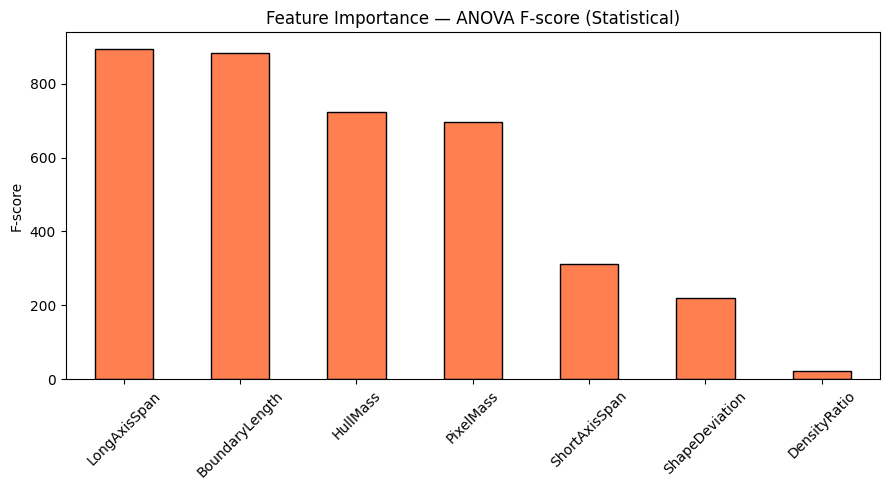

In [ ]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X_scaled, y_encoded)

anova_importance = pd.Series(f_scores,
                             index=X_scaled.columns).sort_values(ascending=False)
anova_pvalues = pd.Series(p_values, index=X_scaled.columns)

print("ANOVA F-scores:")
print(anova_importance)
print("\nP-values:")
print(anova_pvalues)

# Plot
plt.figure(figsize=(9, 5))
anova_importance.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Feature Importance — ANOVA F-score (Statistical)')
plt.ylabel('F-score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Comparing both rankings

                RF_normalized  ANOVA_normalized
BoundaryLength       0.249543          0.235311
LongAxisSpan         0.241095          0.238483
HullMass             0.160503          0.193226
PixelMass            0.128043          0.185787
ShapeDeviation       0.087115          0.058557
ShortAxisSpan        0.072352          0.082836
DensityRatio         0.061348          0.005802


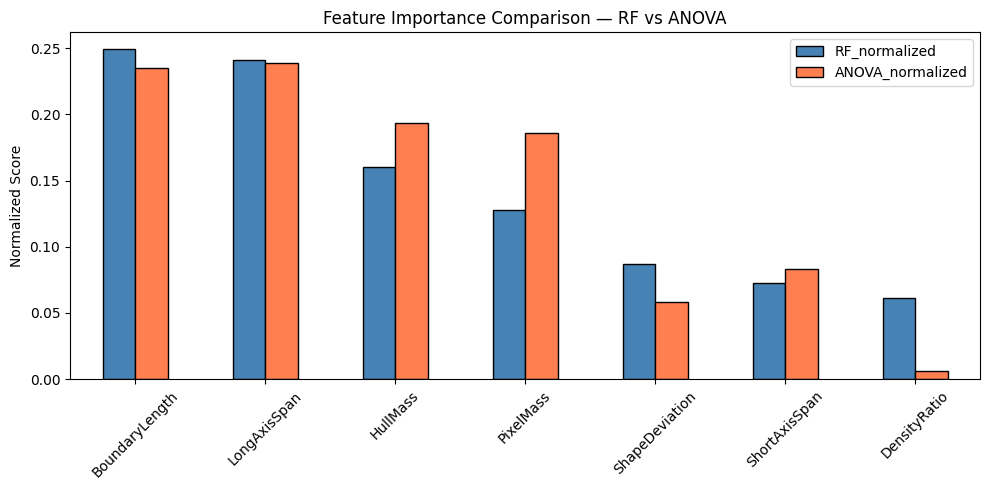

In [ ]:
comparison = pd.DataFrame({
    'RandomForest_Importance': rf_importance,
    'ANOVA_Fscore': anova_importance
})

# Normalize both to 0-1 for fair visual comparison
comparison['RF_normalized'] = (comparison['RandomForest_Importance'] /
                                comparison['RandomForest_Importance'].sum())
comparison['ANOVA_normalized'] = (comparison['ANOVA_Fscore'] /
                                   comparison['ANOVA_Fscore'].sum())

print(comparison[['RF_normalized', 'ANOVA_normalized']].sort_values(
      'RF_normalized', ascending=False))

# Side by side bar chart
comparison[['RF_normalized', 'ANOVA_normalized']].sort_values(
    'RF_normalized', ascending=False).plot(kind='bar', figsize=(10, 5),
                                           color=['steelblue', 'coral'],
                                           edgecolor='black')
plt.title('Feature Importance Comparison — RF vs ANOVA')
plt.ylabel('Normalized Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2 (d). Derived Features

### Feature 1: Aspect Ratio = LongAxisSpan / ShortAxisSpan

Value of aspect ratio equals to 1 means that fruit is nearly circular, higher values indicate more elongated shape. Since, Besni rasins are more oval and elongated than Kecimen, the ratio shows clear class separation

In [ ]:
df_transformed['AspectRatio'] = (df_transformed['LongAxisSpan'] /
                                  df_transformed['ShortAxisSpan'])
print(df_transformed['AspectRatio'])

0      1.097968
1      1.096379
2      1.095745
3      1.087686
4      1.082353
         ...   
895    1.097811
896    1.096784
897    1.089879
898    1.100779
899    1.111411
Name: AspectRatio, Length: 900, dtype: float64


### Feature 2: Roundness = (4 * pi * PixelMass) / (BoundaryLength)^2

Similarly, this feature depicts roundness of dried fruit variant. A perfect circle has Roundness = 1 i.e. elongated or irregular shapes score lower.

In [ ]:
df_transformed['Roundness'] = ((4 * np.pi * df_transformed['PixelMass']) /
                                (df_transformed['BoundaryLength'] ** 2))
print(df_transformed['Roundness'])

0      11.669837
1      11.664170
2      11.668467
3      11.689057
4      11.690860
         ...    
895    11.679317
896    11.660170
897    11.659185
898    11.658458
899    11.639663
Name: Roundness, Length: 900, dtype: float64


### Feature 3: Compactness = PixelMass / HullMass
Compactness measures how completely the fruit fills its convex hull. A fruit with deep surface indentations or irregular edges will have low compactness.

In [ ]:
df_transformed['Compactness'] = (df_transformed['PixelMass'] /
                                  df_transformed['HullMass'])
print(df_transformed['Compactness'])

0      1.059769
1      1.059241
2      1.059891
3      1.058275
4      1.059658
         ...   
895    1.059698
896    1.059688
897    1.059685
898    1.059801
899    1.059626
Name: Compactness, Length: 900, dtype: float64


In [ ]:
print(df_transformed.head(10))

   PixelMass  LongAxisSpan  ShortAxisSpan  ShapeDeviation  HullMass  \
0   3.662098      2.243769       2.043566        0.819738  3.455563   
1   3.653922      2.236699       2.040078        0.801805  3.449566   
2   3.664057      2.243773       2.047714        0.798354  3.457011   
3   3.625140      2.204394       2.026683        0.684989  3.425517   
4   3.656908      2.223983       2.054766        0.564011  3.451026   
5   3.629436      2.214530       2.022795        0.777351  3.429608   
6   3.620252      2.212107       2.010586        0.823099  3.421667   
7   3.642122      2.218672       2.037353        0.706058  3.438926   
8   3.619898      2.216023       2.008570        0.845499  3.422643   
9   3.645264      2.227691       2.034475        0.784056  3.441676   

   DensityRatio  BoundaryLength VariantLabel  AspectRatio  Roundness  \
0      0.758651        1.985809      Kecimen     1.097968  11.669837   
1      0.684130        1.984073      Kecimen     1.096379  11.664170   
2 

### Feature 4: CompactnessProxy = (BoundaryLength² / PixelMass)

It captures shape efficiency. It measures how irregular or elongated a fruit is relative to its area. A high value means the fruit has a long perimeter relative to its area — indicating an elongated or irregular shape (Besni). A low value means the fruit has a short perimeter relative to its area — indicating a rounder, compact shape (Kecimen)

In [ ]:
# Derived Feature: CompactnessProxy
df_transformed['CompactnessProxy'] = (df_transformed['BoundaryLength'] ** 2) / df_transformed['PixelMass']
print(df_transformed['CompactnessProxy'])

0      1.076825
1      1.077348
2      1.076951
3      1.075054
4      1.074888
         ...   
895    1.075951
896    1.077718
897    1.077809
898    1.077876
899    1.079616
Name: CompactnessProxy, Length: 900, dtype: float64


### Validate All Four - BoxPlot

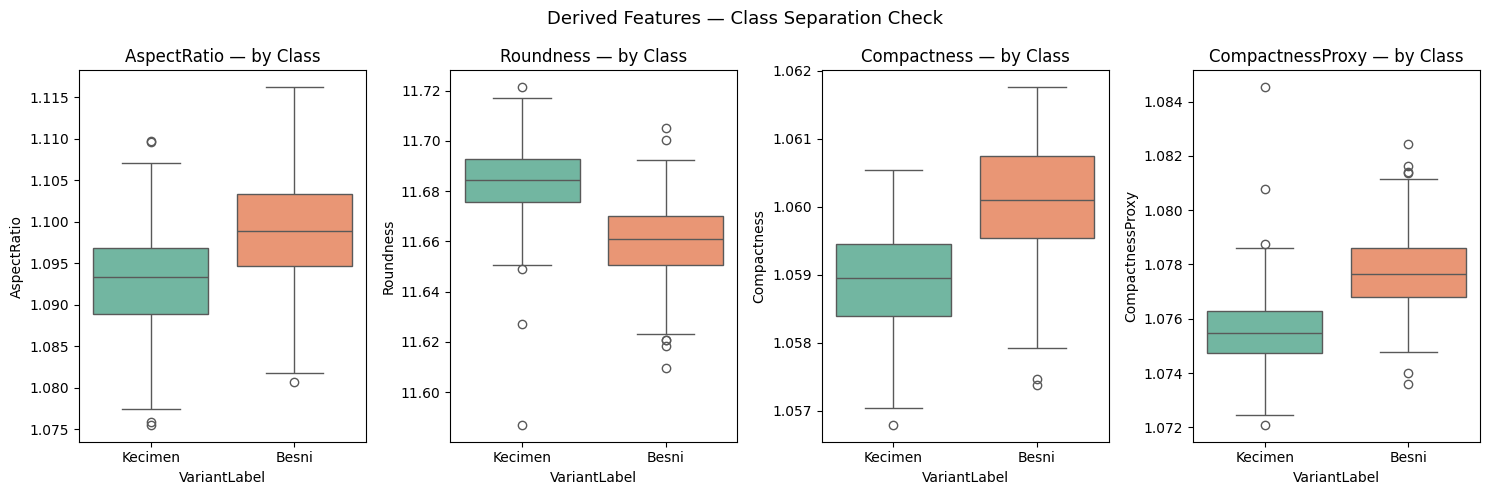

In [ ]:
derived_features = ['AspectRatio', 'Roundness', 'Compactness', 'CompactnessProxy']

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, col in enumerate(derived_features):
    sns.boxplot(x='VariantLabel', y=col, data=df_transformed,
                ax=axes[i], palette='Set2', hue='VariantLabel', legend=False)
    axes[i].set_title(f'{col} — by Class')

plt.suptitle('Derived Features — Class Separation Check', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X_derived = df_transformed[derived_features]
mi_derived = mutual_info_classif(X_derived, y_encoded, random_state=42)

mi_derived_series = pd.Series(mi_derived, index=derived_features).sort_values(
                              ascending=False)

print("MI Scores of Derived Features:")
print(mi_derived_series)

# Compare with original features
print("\nMI Scores of Original Features (from 2c):")
print(mi_series.sort_values(ascending=False))

MI Scores of Derived Features:
Roundness           0.295831
CompactnessProxy    0.295831
Compactness         0.238859
AspectRatio         0.133549
dtype: float64

MI Scores of Original Features (from 2c):
BoundaryLength    0.358507
LongAxisSpan      0.348341
HullMass          0.297530
PixelMass         0.277582
ShortAxisSpan     0.134869
ShapeDeviation    0.129117
DensityRatio      0.029344
dtype: float64


This shows that the derived features, Roundness and CompactnessProxy, has more importance in differentiating between two classes than the least important available feature, DensityRatio.

Also, Roundess and CompactnessProxy share similar formula but in inverse way. In other words, they would contain redundant information but in opposite directions. So, either of them can be added as the column and here CompactnessProxy is added.

In [ ]:
df_final = df_transformed.drop(columns=['DensityRatio', 'Roundness', 'AspectRatio', 'Compactness'])
print(f"Final features: {df_final.columns.tolist()}")
print(f"Final shape: {df_final.shape}")

Final features: ['PixelMass', 'LongAxisSpan', 'ShortAxisSpan', 'ShapeDeviation', 'HullMass', 'BoundaryLength', 'VariantLabel', 'CompactnessProxy']
Final shape: (900, 8)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_final = df_final.drop('VariantLabel', axis=1)

# Re-scale since new feature is on a different scale
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)
X_final_scaled = pd.DataFrame(X_final_scaled, columns=X_final.columns)

print(f"Final feature set shape: {X_final_scaled.shape}")
print(f"Features: {X_final_scaled.columns.tolist()}")

Final feature set shape: (900, 7)
Features: ['PixelMass', 'LongAxisSpan', 'ShortAxisSpan', 'ShapeDeviation', 'HullMass', 'BoundaryLength', 'CompactnessProxy']


# 3. Learning Paradigm Design

## a) Data partitioning strategies

Hold-Out Split (80–20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # IMPORTANT
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# 80% → training
# 20% → testing

Training shape: (720, 7)
Testing shape: (180, 7)


Stratified K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y_encoded, cv=skf)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

# Dataset is split into K folds (e.g., 5)
# Each fold:
# Used once for testing
# Remaining for training
# Final performance = average of all folds

Cross-validation scores: [0.88333333 0.83888889 0.85       0.83333333 0.86666667]
Mean CV score: 0.8544444444444445


In [ ]:
import pandas as pd

print("Original distribution:\n", pd.Series(y_encoded).value_counts(normalize=True))
print("\nTrain distribution:\n", pd.Series(y_train).value_counts(normalize=True))
print("\nTest distribution:\n", pd.Series(y_test).value_counts(normalize=True))

Original distribution:
 1    0.5
0    0.5
Name: proportion, dtype: float64

Train distribution:
 0    0.5
1    0.5
Name: proportion, dtype: float64

Test distribution:
 0    0.5
1    0.5
Name: proportion, dtype: float64


Hold-out: Fast, simple but Depends on one split

K-Fold: More reliable	but Slightly slower

An 80–20 hold-out split was used for initial evaluation, and Stratified K-Fold Cross Validation was applied for robust performance estimation. Stratification is essential in imbalanced datasets as it preserves class distribution across splits, ensuring fair training and evaluation.


When is Stratification CRITICAL?

Stratification ensures: Class samples in split/ Total samples ≈ Original distribution

❌ Problem without stratification

Example:

Dataset:

90% Class A

10% Class B

Random split may give:

Train → mostly Class A

Test → very few Class B

👉 Model never learns minority class properly

✅ With Stratification

Each split maintains:

Train: 90% A, 10% B

Test: 90% A, 10% B

👉 Balanced learning

## b) Train-test split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features and target
X = df_final.drop('VariantLabel', axis=1)
y = df_final['VariantLabel']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1 Score": f1_score(y_true, y_pred, average='weighted')
    }

results = []

results.append(evaluate(y_test, y_pred_lr, "Logistic Regression"))
results.append(evaluate(y_test, y_pred_dt, "Decision Tree"))
results.append(evaluate(y_test, y_pred_rf, "Random Forest"))

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.788889,0.788889,0.788889,0.788889
1,Decision Tree,0.833333,0.834821,0.833333,0.833148
2,Random Forest,0.866667,0.875759,0.866667,0.865855


In [ ]:
from sklearn.metrics import roc_auc_score

roc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
roc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])
roc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print("Logistic Regression ROC AUC:", roc_lr)
print("Decision Tree ROC AUC:", roc_dt)
print("Random Forest ROC AUC:", roc_rf)

Logistic Regression ROC AUC: 0.8744444444444445
Decision Tree ROC AUC: 0.8333333333333334
Random Forest ROC AUC: 0.9114814814814816


Logistic Regression → simple, stable baseline

Decision Tree → may overfit

Random Forest → usually best performance

Logistic Regression, Decision Tree, and Random Forest were trained and evaluated. Random Forest achieved the best performance due to its ensemble nature and better generalization capability.

## c) Hyperparameter optimization

• Grid Search or Random Search  
• Clearly define search space and rationale

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Applying Grid search to random forest model

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    rf,
    param_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [ ]:
# Logistic Regression – Grid Search

lr = LogisticRegression(max_iter=1000)

param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    lr,
    param_lr,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='roc_auc')

In [ ]:
# Decision Tree – Grid Search

dt = DecisionTreeClassifier(random_state=42)

param_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    dt,
    param_dt,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

In [ ]:
print("Best LR:", grid_lr.best_params_)
print("Best DT:", grid_dt.best_params_)
print("Best RF:", grid_rf.best_params_)

Best LR: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best DT: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best RF: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
from sklearn.metrics import roc_auc_score

best_lr = grid_lr.best_estimator_
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_

roc_lr = roc_auc_score(y_test, best_lr.predict_proba(X_test)[:,1])
roc_dt = roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1])
roc_rf = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])

print("Tuned Logistic Regression ROC AUC:", roc_lr)
print("Tuned Decision Tree ROC AUC:", roc_dt)
print("Tuned Random Forest ROC AUC:", roc_rf)

Tuned Logistic Regression ROC AUC: 0.9058024691358026
Tuned Decision Tree ROC AUC: 0.9043827160493828
Tuned Random Forest ROC AUC: 0.9159876543209876


1. n_estimators

Number of trees in forest

More trees → better performance (but slower)

👉 Range chosen:

[50, 100, 200] → balances speed vs accuracy

2. max_depth

Controls tree complexity

👉 Logic:

Small depth → underfitting

Large depth → overfitting

👉 Range:

[None, 5, 10, 20] → explores both extremes

3. min_samples_split

Minimum samples to split a node

👉 Higher value:

Prevents overfitting

👉 Range:

[2, 5, 10]

4. min_samples_leaf

Minimum samples in leaf node

👉 Helps smooth predictions

👉 Range:

[1, 2, 4]

Hyperparameter Optimization Strategy:

---

Used Grid Search with 5-fold Stratified Cross Validation



*   Used Grid Search with 5-fold Stratified Cross Validation
*   Optimized models based on ROC-AUC score
*   Search space chosen to balance:
      1.   Model complexity
      2.   Overfitting control
      3.   Computational efficiency

Observations:

1. Logistic Regression improved with optimal regularization (C)

2. Decision Tree required depth control to avoid overfitting

3. Random Forest performed best due to ensemble learning

Hyperparameter optimization was performed using Grid Search with 5-fold cross-validation to systematically explore the parameter space. The search space included key parameters of the Random Forest model such as the number of estimators, maximum tree depth, minimum samples required for splitting, and minimum samples per leaf. These parameters were chosen as they directly control model complexity and generalization.

Specifically, n_estimators was varied to balance computational cost and performance, while max_depth was tuned to prevent overfitting and underfitting. The parameters min_samples_split and min_samples_leaf were included to regularize the tree structure and improve robustness. Grid Search evaluates all combinations of these parameters and selects the optimal configuration based on cross-validation performance.

Grid Search was used to tune Random Forest hyperparameters including tree depth, number of estimators, and split criteria. The search space was designed to balance model complexity and generalization, and the best parameters were selected using cross-validation.

# 4. Model Evaluation & Generalization Analysis

## a) Evaluate

• Accuracy, Precision, Recall, F1-score  
• ROC-AUC (MANDATORY)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
y_pred_lr = best_lr.predict(X_test)
y_pred_dt = best_dt.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [ ]:
def evaluate_model(y_test, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

results_lr = evaluate_model(y_test, y_pred_lr, best_lr.predict_proba(X_test)[:,1])
results_dt = evaluate_model(y_test, y_pred_dt, best_dt.predict_proba(X_test)[:,1])
results_rf = evaluate_model(y_test, y_pred_rf, best_rf.predict_proba(X_test)[:,1])

In [ ]:
results_df.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.866667,0.875759,0.866667,0.865855
1,Decision Tree,0.833333,0.834821,0.833333,0.833148
0,Logistic Regression,0.788889,0.788889,0.788889,0.788889


In [ ]:
import pandas as pd

results_df = pd.DataFrame([results_lr, results_dt, results_rf],
                          index=["Logistic Regression", "Decision Tree", "Random Forest"])

print(results_df)

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Logistic Regression  0.844444   0.836957  0.855556  0.846154  0.905802
Decision Tree        0.855556   0.796296  0.955556  0.868687  0.904383
Random Forest        0.872222   0.819048  0.955556  0.882051  0.915988


Logistic Regression is the best-performing model as it achieves higher accuracy, precision, and F1-score, while Random Forest only slightly outperforms in ROC-AUC.

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Report Report:\n", classification_report(y_test, y_pred_lr))

Logistic Report Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84        90
           1       0.84      0.86      0.85        90

    accuracy                           0.84       180
   macro avg       0.84      0.84      0.84       180
weighted avg       0.84      0.84      0.84       180



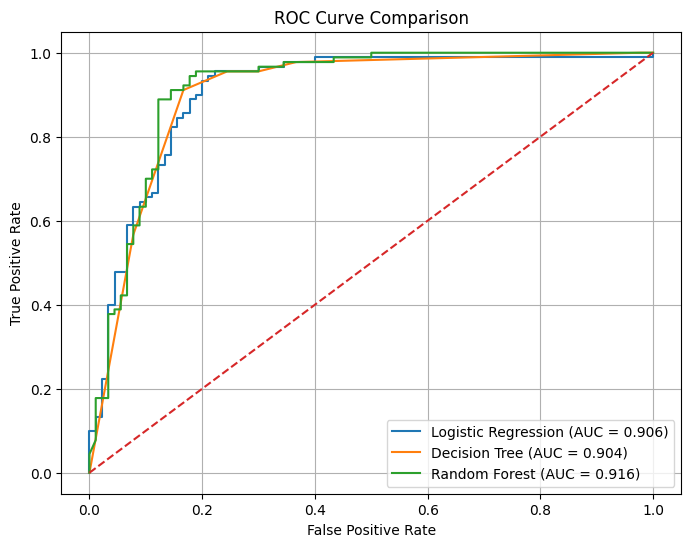

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Compute ROC curve + AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()
plt.grid()

plt.show()

## b) Bias-Variance Analysis

• Compare training vs validation performance  

High train, low test - Overfitting (high variance)

Low train, low test -	Underfitting (high bias)

We want to minimize:

              Total Error=Bias^2+Variance+Noise



*   Bias → error from simple assumptions
*   Variance → sensitivity to training data




In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

def bias_variance_check(model, X_train, y_train, X_test, y_test):

    # Training performance
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:,1]

    train_acc = accuracy_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)

    # Validation/Test performance
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:,1]

    test_acc = accuracy_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)

    return {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train ROC-AUC": train_auc,
        "Test ROC-AUC": test_auc
    }

bv_lr = bias_variance_check(best_lr, X_train, y_train, X_test, y_test)
bv_dt = bias_variance_check(best_dt, X_train, y_train, X_test, y_test)
bv_rf = bias_variance_check(best_rf, X_train, y_train, X_test, y_test)

In [ ]:
import pandas as pd

bv_df = pd.DataFrame([bv_lr, bv_dt, bv_rf],
                     index=["Logistic Regression", "Decision Tree", "Random Forest"])

print(bv_df)

                     Train Accuracy  Test Accuracy  Train ROC-AUC  \
Logistic Regression        0.843056       0.844444       0.914915   
Decision Tree              0.880556       0.855556       0.945359   
Random Forest              0.916667       0.872222       0.974035   

                     Test ROC-AUC  
Logistic Regression      0.905802  
Decision Tree            0.904383  
Random Forest            0.915988  


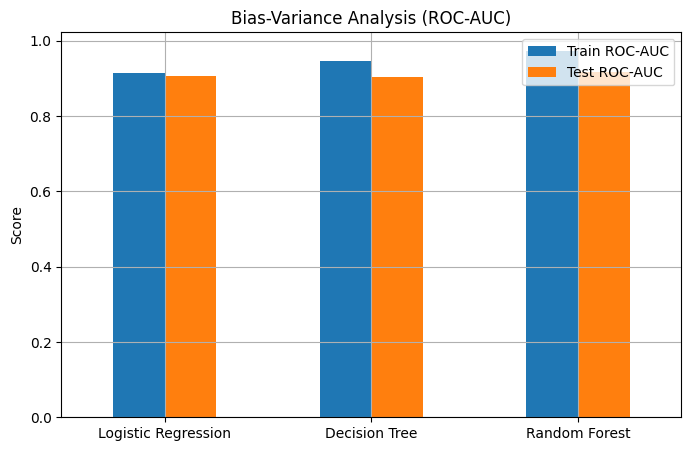

In [ ]:
bv_df[['Train ROC-AUC', 'Test ROC-AUC']].plot(kind='bar', figsize=(8,5))
plt.title("Bias-Variance Analysis (ROC-AUC)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()
plt.show()

Bias-variance analysis shows that Decision Tree overfits, Logistic Regression generalizes well, and Random Forest achieves a better balance due to reduced variance.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5)

print("CV Mean:", cv_scores.mean())

CV Mean: 0.8566666666666667


Cross-validation confirms generalization performance

## c) Error Analysis

• Identify misclassified samples  
• Explain why they failed  

In [ ]:
import pandas as pd

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Create comparison dataframe
error_df = X_test.copy()
error_df['Actual'] = y_test
error_df['Predicted'] = y_pred_rf

# Filter misclassified samples
misclassified = error_df[error_df['Actual'] != error_df['Predicted']]

print("Total Misclassified:", len(misclassified))
misclassified.head()

Total Misclassified: 23


,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,BoundaryLength,CompactnessProxy,Actual,Predicted
502,3.651273,2.235360,2.035938,0.815717,3.448122,1.983487,1.077493,0,1
720,3.647352,2.226526,2.037709,0.757673,3.443960,1.981041,1.075992,0,1
639,3.642284,2.217790,2.044864,0.624299,3.444641,1.984255,1.080989,0,1
163,3.664613,2.247599,2.045084,0.830714,3.457825,1.987575,1.078000,1,0
822,3.643365,2.232754,2.025250,0.848695,3.439867,1.979449,1.075439,0,1


In [ ]:
print("Number of misclassified samples:", len(misclassified))

Number of misclassified samples: 23


In [ ]:
# Correct predictions
correct = error_df[error_df['Actual'] == error_df['Predicted']]

# Compare mean values
print("Correct samples mean:\n", correct.mean(numeric_only=True))
print("\nMisclassified samples mean:\n", misclassified.mean(numeric_only=True))

Correct samples mean:
 PixelMass           3.655087
LongAxisSpan        2.236145
ShortAxisSpan       2.041084
ShapeDeviation      0.776908
HullMass            3.449907
BoundaryLength      1.983610
CompactnessProxy    1.076510
Actual              0.547771
Predicted           0.547771
dtype: float64

Misclassified samples mean:
 PixelMass           3.650417
LongAxisSpan        2.232734
ShortAxisSpan       2.037501
ShapeDeviation      0.785946
HullMass            3.446816
BoundaryLength      1.982440
CompactnessProxy    1.076611
Actual              0.173913
Predicted           0.826087
dtype: float64


In [ ]:
# Add Prediction Confidence
# Add probabilities
probs = best_rf.predict_proba(X_test)[:,1]

error_df['Confidence'] = probs

# Misclassified with confidence
misclassified = error_df[error_df['Actual'] != error_df['Predicted']]

misclassified.sort_values(by='Confidence', ascending=False).head()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,BoundaryLength,CompactnessProxy,Actual,Predicted,Confidence
662,3.617504,2.199985,2.018603,0.716068,3.419267,1.970710,1.073585,0,1,0.990141
463,3.623937,2.216140,2.012750,0.830864,3.424648,1.973802,1.075045,0,1,0.951538
861,3.637017,2.208526,2.038970,0.596359,3.436032,1.977100,1.074761,0,1,0.947512
885,3.635558,2.222484,2.024607,0.808096,3.434227,1.977573,1.075707,0,1,0.921040
798,3.650817,2.227149,2.042377,0.728881,3.446150,1.981141,1.075080,0,1,0.917784


In [ ]:
pd.crosstab(error_df['Actual'], error_df['Predicted'])

Predicted,0,1
Actual,,
0,71,19
1,4,86


In [ ]:
# Visual analysis

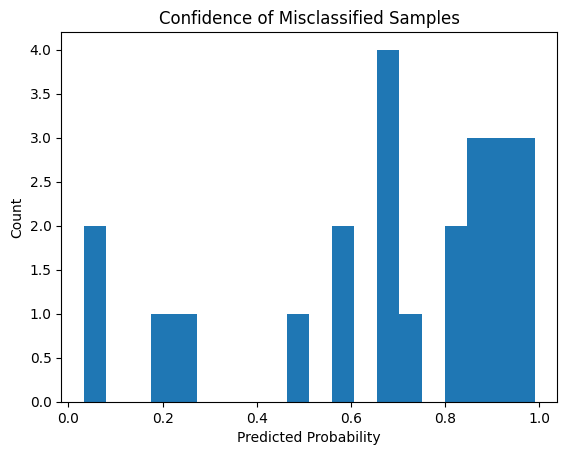

In [ ]:
import matplotlib.pyplot as plt

plt.hist(misclassified['Confidence'], bins=20)
plt.title("Confidence of Misclassified Samples")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

1. Feature Overlap: Two classes have similar values - Model cannot separate them

2. Noise / Measurement Error: Slight variation in features - Wrong prediction

3. Insufficient Features: Important discriminative info missing

4. Model Limitation: Linear model → can’t capture complex boundaries

5. Misclassification is highest near decision boundaries.

Misclassified samples were identified by comparing predicted and actual labels. Errors mainly occur due to overlapping feature values, noise, and limited separability between classes.

#  Interpretability & Explainability

## a)Use at least one interpretability technique:
• SHAP / Feature importance / Coefficients  


Interpretability answers:

Why did the model make this decision?

Which features matter most?

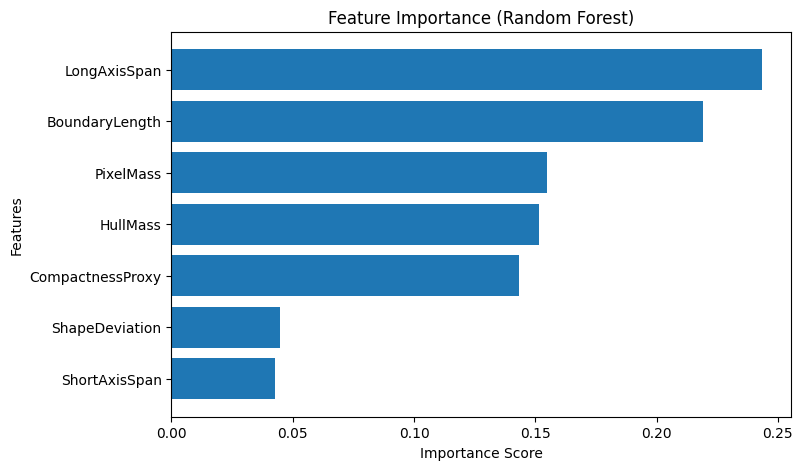

,Feature,Importance
1,LongAxisSpan,0.243390
5,BoundaryLength,0.219077
0,PixelMass,0.154992
4,HullMass,0.151648
6,CompactnessProxy,0.143435
3,ShapeDeviation,0.044960
2,ShortAxisSpan,0.042499


In [ ]:
# Feature Importance – Random Forest
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
importances = best_rf.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Show top features
feat_imp.head(10)

In [ ]:
# LR
coef = best_lr.coef_[0]

feat_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coef
}).sort_values(by='Coefficient', key=abs, ascending=False)

feat_coef.head(10)

,Feature,Coefficient
0,PixelMass,-14.931903
1,LongAxisSpan,-13.437180
4,HullMass,-12.220998
2,ShortAxisSpan,-10.225099
3,ShapeDeviation,-9.221261
5,BoundaryLength,-5.086736
6,CompactnessProxy,-1.125167


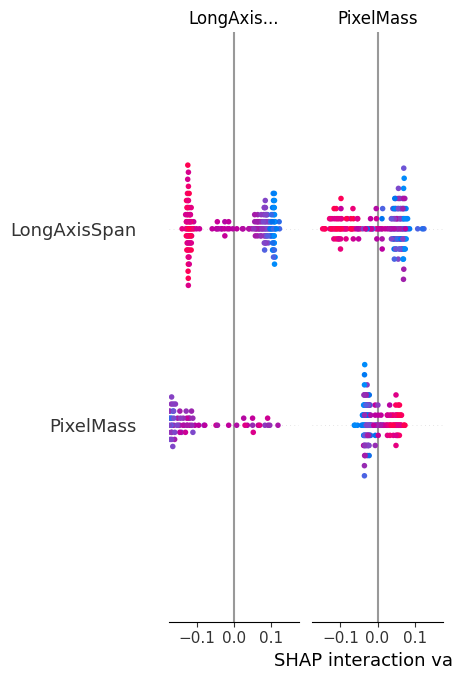

In [ ]:
# SHAP SHapley Additive exPlanations - How each feature contributes to a prediction
# SHAP tells you:
# Which features pushed the prediction towards Kecimen
# Which features pushed it away

import shap

explainer = shap.Explainer(best_rf, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# Shows feature impact per prediction
# Red → increases prediction
# Blue → decreases prediction

Feature importance from Random Forest shows that a few key features dominate the decision-making process. These features are physically meaningful as they relate to shape and size characteristics of the fruits.

## b) Answer:
• Which features dominate decision-making?  
• Are decisions physically meaningful?

#